# Partie 1 — Chargement & analyse exploratoire (EDA)

**Projet CarPredictor** — estimation du prix de revente d'un véhicule d'occasion.

Objectifs de ce notebook :

1. Charger le jeu de données brut et vérifier sa structure (types, dimensions).
2. Produire les statistiques descriptives (moyennes, médianes, écarts-types, fréquences).
3. Visualiser les distributions (kilométrage, prix, année).
4. Étudier les corrélations et l'impact de `year` et `km_driven` sur `selling_price`
   (matrice de corrélation, heatmap, pairplot, nuages de points).
5. **Justifier** quelles colonnes sont réellement pertinentes pour la prédiction.

> Le nettoyage (valeurs manquantes, doublons, aberrantes), l'encodage, la séparation
> train/test et la normalisation sont traités dans le notebook suivant
> `01b_nettoyage_preparation.ipynb`. Ici, on **observe sans modifier** : toute l'analyse
> est faite sur les données brutes afin de diagnostiquer les problèmes à corriger.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


RAW_PATH = "../data/raw/car-price-raw-data.csv"
FIG_DIR = "../reports/figures"


---
## 1. Chargement des données et structure

In [3]:
df = pd.read_csv(RAW_PATH)
df.head(10)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007.0,60000,70000.0,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007.0,135000,50000.0,Petrol,Individual,Manual,NaN
2,Hyundai Verna 1.6 SX,2012.0,600000,100000.0,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017.0,250000,46000.0,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014.0,450000,141000.0,Diesel,Individual,Manual,Second Owner
5,Maruti Alto LX BSIII,2007.0,140000,125000.0,Petrol,Individual,Manual,First Owner
6,Hyundai Xcent 1.2 Kappa S,2016.0,550000,25000.0,Petrol,Individual,Manual,First Owner
7,Tata Indigo Grand Petrol,2014.0,240000,60000.0,Petrol,Individual,Manual,Second Owner
8,Hyundai Creta 1.6 VTVT S,2015.0,850000,25000.0,Petrol,Individual,Manual,First Owner
9,Maruti Celerio Green VXI,2017.0,365000,78000.0,CNG,Individual,Manual,First Owner


In [4]:
print(f"Dimensions : {df.shape[0]} lignes x {df.shape[1]} colonnes\n")
print("Types des colonnes :")
print(df.dtypes)

Dimensions : 4340 lignes x 8 colonnes

Types des colonnes :
name                 str
year             float64
selling_price      int64
km_driven        float64
fuel                 str
seller_type          str
transmission         str
owner                str
dtype: object


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           4340 non-null   str    
 1   year           4297 non-null   float64
 2   selling_price  4340 non-null   int64  
 3   km_driven      4167 non-null   float64
 4   fuel           4254 non-null   str    
 5   seller_type    4275 non-null   str    
 6   transmission   4340 non-null   str    
 7   owner          4254 non-null   str    
dtypes: float64(2), int64(1), str(5)
memory usage: 271.4 KB


In [6]:
# Vue synthétique : type, nb de valeurs manquantes, nb de modalités distinctes, exemple
structure = pd.DataFrame({
    "type": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "manquants": df.isna().sum(),
    "% manquants": (df.isna().mean() * 100).round(2),
    "valeurs_uniques": df.nunique(),
    "exemple": [df[col].dropna().iloc[0] for col in df.columns],
})
structure

,type,non_null,manquants,% manquants,valeurs_uniques,exemple
name,str,4340,0,0.00,1491,Maruti 800 AC
year,float64,4297,43,0.99,27,2007.0
selling_price,int64,4340,0,0.00,445,60000
km_driven,float64,4167,173,3.99,750,70000.0
fuel,str,4254,86,1.98,5,Petrol
seller_type,str,4275,65,1.50,3,Individual
transmission,str,4340,0,0.00,2,Manual
owner,str,4254,86,1.98,5,First Owner


### Lecture de la structure

Le fichier contient **4 340 lignes** et **8 colonnes**.

| Colonne | Type lu | Rôle attendu |
|---|---|---|
| `name` | texte | identifiant commercial du modèle (très haute cardinalité) |
| `year` | `float64` | année de mise en circulation — **numérique** |
| `selling_price` | `int64` | **variable cible** (prix de vente) |
| `km_driven` | `float64` | kilométrage — **numérique** |
| `fuel` | texte | carburant — **catégoriel** |
| `seller_type` | texte | type de vendeur — **catégoriel** |
| `transmission` | texte | boîte de vitesses — **catégoriel binaire** |
| `owner` | texte | nombre de propriétaires précédents — **catégoriel ordinal** |

Deux remarques sur les types :

- `year` et `km_driven` sont lus en `float64` **uniquement à cause des valeurs manquantes**
  (une colonne entière contenant des `NaN` est promue en flottant). Ce sont bien des entiers
  logiques : on pourra les recaster en `Int64` après imputation.
- `owner` est stocké en texte (`First Owner`, `Second Owner`, …) alors qu'il porte un **ordre**.
  Cet ordre devra être conservé lors de l'encodage (encodage ordinal, et non one-hot).

---
## 2. Statistiques descriptives

### 2.1 Variables numériques

In [7]:
num_cols = ["year", "km_driven", "selling_price"]
cat_cols = ["fuel", "seller_type", "transmission", "owner"]

desc = df[num_cols].describe().T
desc["median"] = df[num_cols].median()
desc["skew"] = df[num_cols].skew()          # asymétrie
desc["kurtosis"] = df[num_cols].kurtosis()  # aplatissement
desc["IQR"] = desc["75%"] - desc["25%"]
desc[["count", "mean", "median", "std", "min", "25%", "50%", "75%", "max", "IQR", "skew", "kurtosis"]]

,count,mean,median,std,min,25%,50%,75%,max,IQR,skew,kurtosis
year,4297.0,2013.087736,2014.0,4.219918,1992.0,2011.00,2014.0,2016.0,2020.0,5.00,-0.835206,0.675389
km_driven,4167.0,66237.198224,60000.0,46635.456187,1.0,35000.00,60000.0,90000.0,806599.0,55000.00,2.713426,24.118287
selling_price,4340.0,504127.311751,350000.0,578548.736139,20000.0,208749.75,350000.0,600000.0,8900000.0,391250.25,4.892021,37.087543


In [8]:
# Quantiles fins : utiles pour situer les queues de distribution
df[num_cols].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.995]).T

,0.010,0.050,0.250,0.500,0.750,0.950,0.990,0.995
year,2001.0,2005.0,2011.00,2014.0,2016.0,2019.0,2020.0,2020.0
km_driven,1426.4,10000.0,35000.00,60000.0,90000.0,140000.0,218680.0,250000.0
selling_price,55000.0,80000.0,208749.75,350000.0,600000.0,1300000.0,3200000.0,4261000.0


**Lecture des statistiques numériques**

- `selling_price` : moyenne ≈ **504 127** contre une médiane de **350 000**. La moyenne est
  ~1,4× la médiane et l'asymétrie (*skew*) vaut **+4,9** → distribution très étalée à droite,
  tirée par quelques véhicules de luxe (max = 8 900 000). **La médiane est ici un bien
  meilleur résumé que la moyenne**, ce qui justifiera l'imputation par la médiane.
- `km_driven` : médiane **60 000 km**, moyenne **66 237 km**, max **806 599 km**.
  Asymétrie **+2,7** → là aussi une longue queue à droite, avec des valeurs physiquement
  douteuses à inspecter.
- `year` : médiane **2014**, min **1992**, max **2020**. Asymétrie **-0,84** (queue à gauche) :
  le parc est majoritairement récent, avec quelques véhicules anciens.

L'écart systématique entre moyenne et médiane sur les deux variables monétaire/kilométrique
est le premier signal de la présence de valeurs extrêmes.

### 2.2 Variables catégorielles — fréquences

In [9]:
for col in cat_cols:
    freq = df[col].value_counts(dropna=False).to_frame("effectif")
    freq["%"] = (df[col].value_counts(dropna=False, normalize=True) * 100).round(2)
    print(f"--- {col} ({df[col].nunique()} modalités) ---")
    print(freq, "\n")

--- fuel (5 modalités) ---
          effectif      %
fuel                     
Diesel        2116  48.76
Petrol        2077  47.86
NaN             86   1.98
CNG             38   0.88
LPG             22   0.51
Electric         1   0.02 

--- seller_type (3 modalités) ---
                  effectif      %
seller_type                      
Individual            3198  73.69
Dealer                 976  22.49
Trustmark Dealer       101   2.33
NaN                     65   1.50 

--- transmission (2 modalités) ---
              effectif      %
transmission                 
Manual            3892  89.68
Automatic          448  10.32 

--- owner (5 modalités) ---
                      effectif      %
owner                                
First Owner               2771  63.85
Second Owner              1084  24.98
Third Owner                302   6.96
NaN                         86   1.98
Fourth & Above Owner        80   1.84
Test Drive Car              17   0.39 



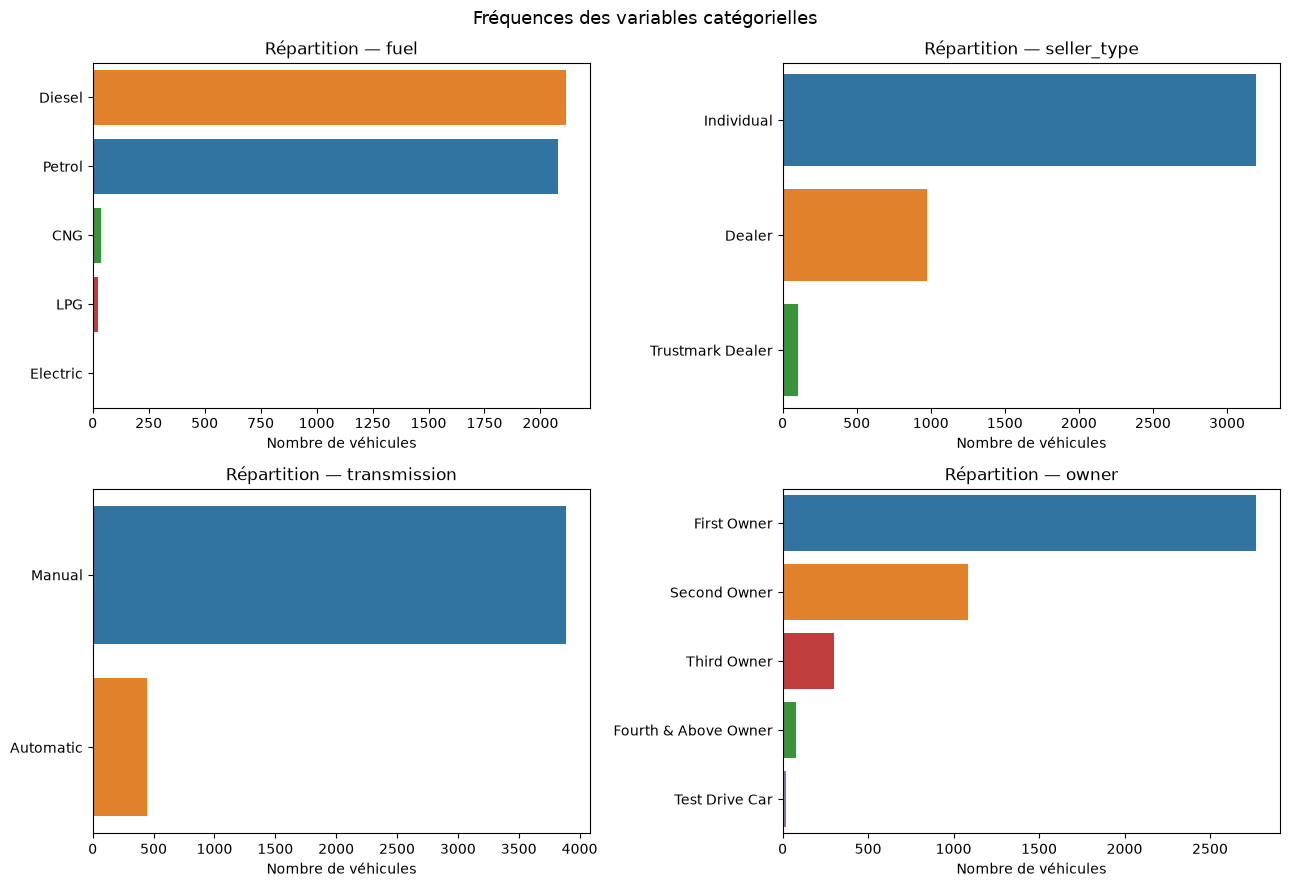

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.ravel(), cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax, hue=col, legend=False)
    ax.set_title(f"Répartition — {col}")
    ax.set_xlabel("Nombre de véhicules")
    ax.set_ylabel("")
fig.suptitle("Fréquences des variables catégorielles", fontsize=13)
fig.tight_layout()
plt.show()

**Lecture des fréquences**

- `fuel` : **Diesel (2 116)** et **Petrol (2 077)** représentent ~97 % des observations.
  `CNG` (38), `LPG` (22) et surtout **`Electric` (1 seule ligne)** sont ultra-minoritaires :
  une modalité à un seul individu n'est pas apprenable et risque de se retrouver
  exclusivement dans le train ou le test après découpage.
- `seller_type` : **Individual (3 198)**, `Dealer` (976), `Trustmark Dealer` (101) — déséquilibré
  mais les trois modalités restent exploitables.
- `transmission` : **Manual (3 892)** vs `Automatic` (448) — variable binaire, ~10 % d'automatiques.
- `owner` : `First Owner` (2 771) → `Fourth & Above Owner` (80), plus une modalité
  **`Test Drive Car` (17)** qui n'est pas un rang de propriétaire mais un statut particulier
  (véhicule de démonstration, quasi neuf).

`name` compte **1 491 modalités distinctes** pour 4 340 lignes (~1 ligne sur 3 est un modèle unique) :
inexploitable telle quelle (voir §5).

---
## 3. Distributions : kilométrage, prix, année

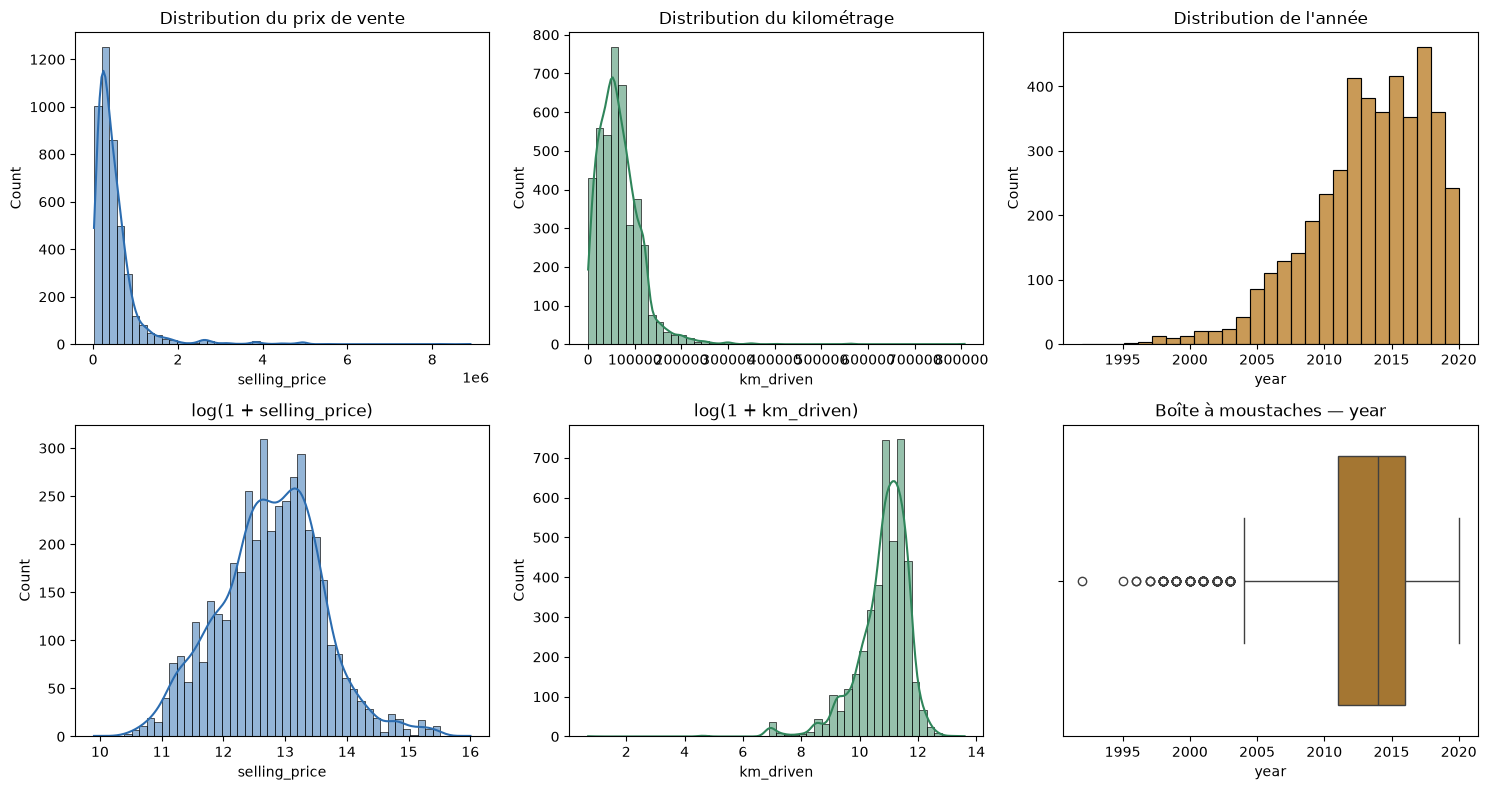

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

sns.histplot(df["selling_price"], bins=50, kde=True, ax=axes[0, 0], color="#2b6cb0")
axes[0, 0].set_title("Distribution du prix de vente")
axes[0, 0].set_xlabel("selling_price")

sns.histplot(df["km_driven"], bins=50, kde=True, ax=axes[0, 1], color="#2f855a")
axes[0, 1].set_title("Distribution du kilométrage")
axes[0, 1].set_xlabel("km_driven")

sns.histplot(df["year"].dropna(), bins=int(df["year"].nunique()), ax=axes[0, 2], color="#b7791f")
axes[0, 2].set_title("Distribution de l'année")
axes[0, 2].set_xlabel("year")

# Même distributions en échelle log : rend la forme lisible malgré la queue droite
sns.histplot(np.log1p(df["selling_price"]), bins=50, kde=True, ax=axes[1, 0], color="#2b6cb0")
axes[1, 0].set_title("log(1 + selling_price)")

sns.histplot(np.log1p(df["km_driven"].dropna()), bins=50, kde=True, ax=axes[1, 1], color="#2f855a")
axes[1, 1].set_title("log(1 + km_driven)")

sns.boxplot(x=df["year"], ax=axes[1, 2], color="#b7791f")
axes[1, 2].set_title("Boîte à moustaches — year")

fig.tight_layout()
plt.show()

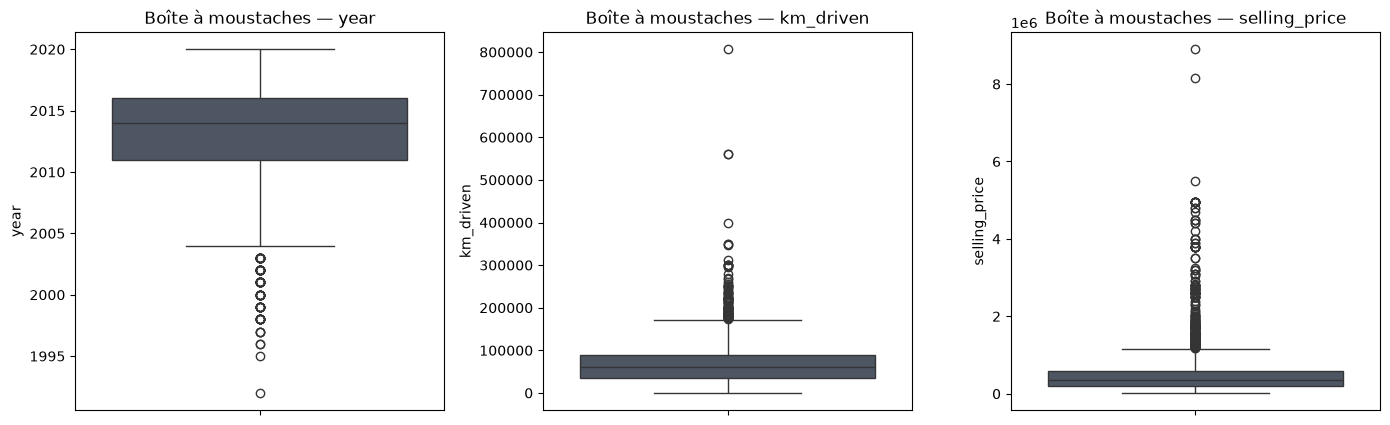

In [12]:
# Boîtes à moustaches des 3 variables numériques : première détection visuelle des aberrantes
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax, color="#4a5568")
    ax.set_title(f"Boîte à moustaches — {col}")
fig.tight_layout()
plt.show()

**Lecture des distributions**

- **Prix** : distribution unimodale fortement asymétrique à droite. En échelle logarithmique,
  elle devient quasi normale → indice fort qu'une transformation `log` de la cible (ou des
  modèles robustes type arbres/ensembles) sera préférable à une régression linéaire brute.
- **Kilométrage** : même profil, avec une poignée de points au-delà de **300 000 km**
  (dont un **806 599 km**) très détachés du reste du nuage.
- **Année** : concentration sur **2010-2019**, queue gauche jusqu'à 1992. Les boîtes à
  moustaches signalent les années anciennes comme « atypiques » au sens statistique,
  mais elles restent parfaitement **plausibles** (un véhicule de 1995 existe).

C'est cette distinction — *atypique statistiquement* ≠ *incohérent* — qui guidera le
traitement des valeurs aberrantes dans le notebook suivant.

---
## 4. Corrélations et impact de l'année et du kilométrage sur le prix

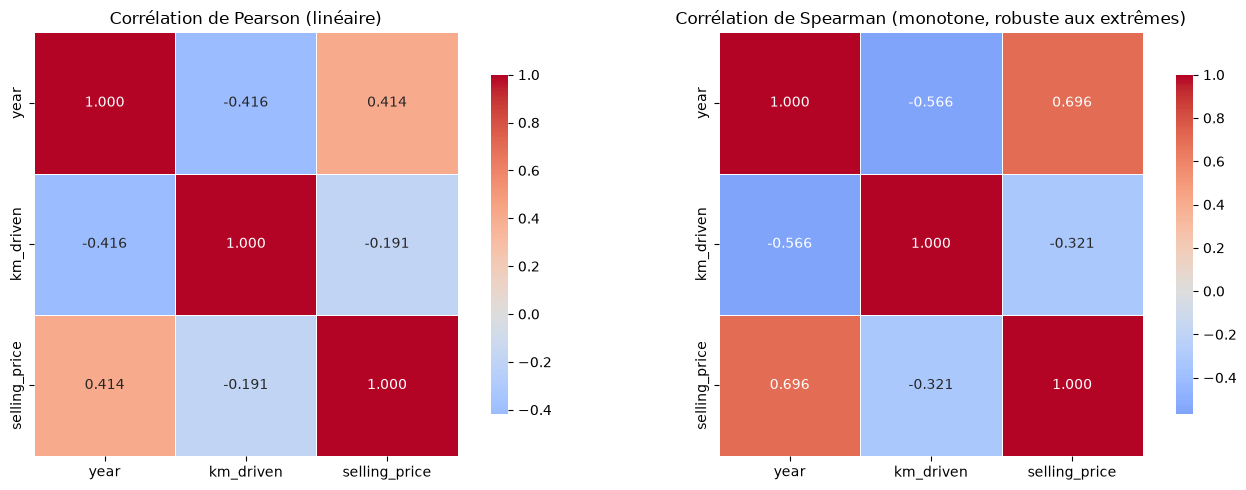

,year,km_driven,selling_price
year,1.000000,-0.415963,0.413501
km_driven,-0.415963,1.000000,-0.190745
selling_price,0.413501,-0.190745,1.000000


In [13]:
corr = df[num_cols].corr(method="pearson")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .8}, ax=axes[0])
axes[0].set_title("Corrélation de Pearson (linéaire)")

corr_s = df[num_cols].corr(method="spearman")
sns.heatmap(corr_s, annot=True, fmt=".3f", cmap="coolwarm", center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .8}, ax=axes[1])
axes[1].set_title("Corrélation de Spearman (monotone, robuste aux extrêmes)")

fig.tight_layout()
plt.show()

corr

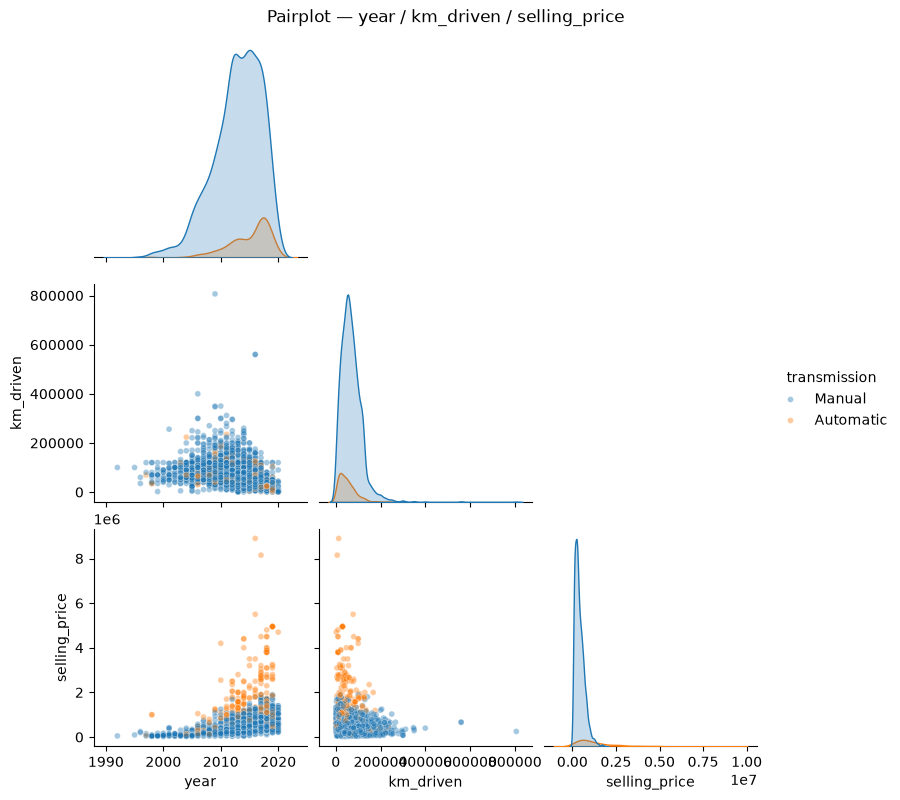

In [14]:
# Pairplot : distributions marginales + relations deux à deux, colorées par transmission
sample = df[num_cols + ["transmission"]].dropna()
g = sns.pairplot(sample, hue="transmission", corner=True, plot_kws={"alpha": .4, "s": 18},
                 diag_kind="kde", height=2.6)
g.figure.suptitle("Pairplot — year / km_driven / selling_price", y=1.02)
plt.show()

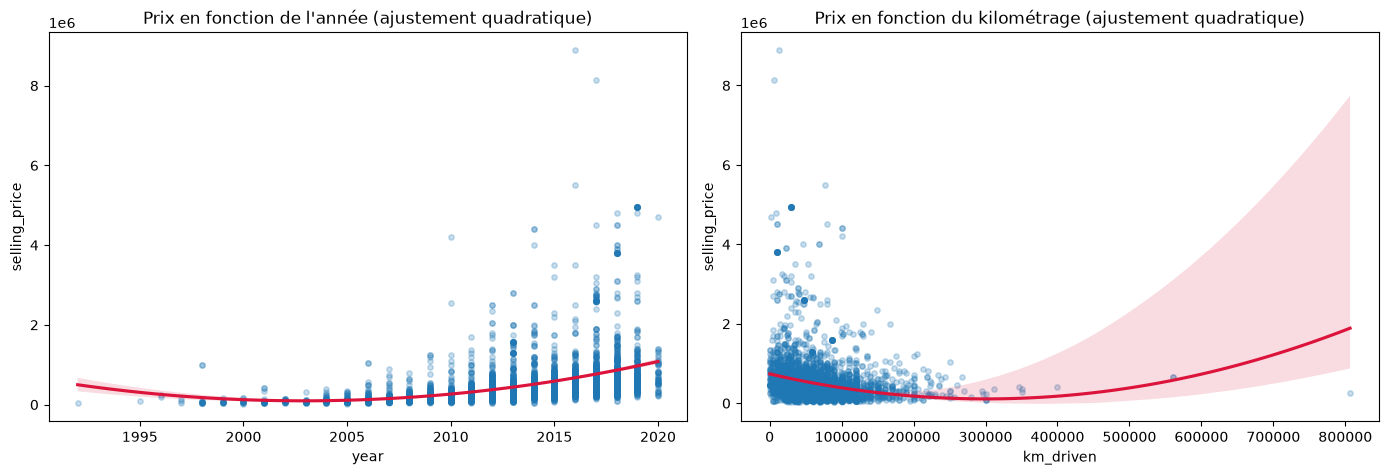

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(data=df, x="year", y="selling_price", ax=axes[0],
            scatter_kws={"alpha": .25, "s": 15}, line_kws={"color": "crimson"}, order=2)
axes[0].set_title("Prix en fonction de l'année (ajustement quadratique)")

sns.regplot(data=df, x="km_driven", y="selling_price", ax=axes[1],
            scatter_kws={"alpha": .25, "s": 15}, line_kws={"color": "crimson"}, order=2)
axes[1].set_title("Prix en fonction du kilométrage (ajustement quadratique)")

fig.tight_layout()
plt.show()

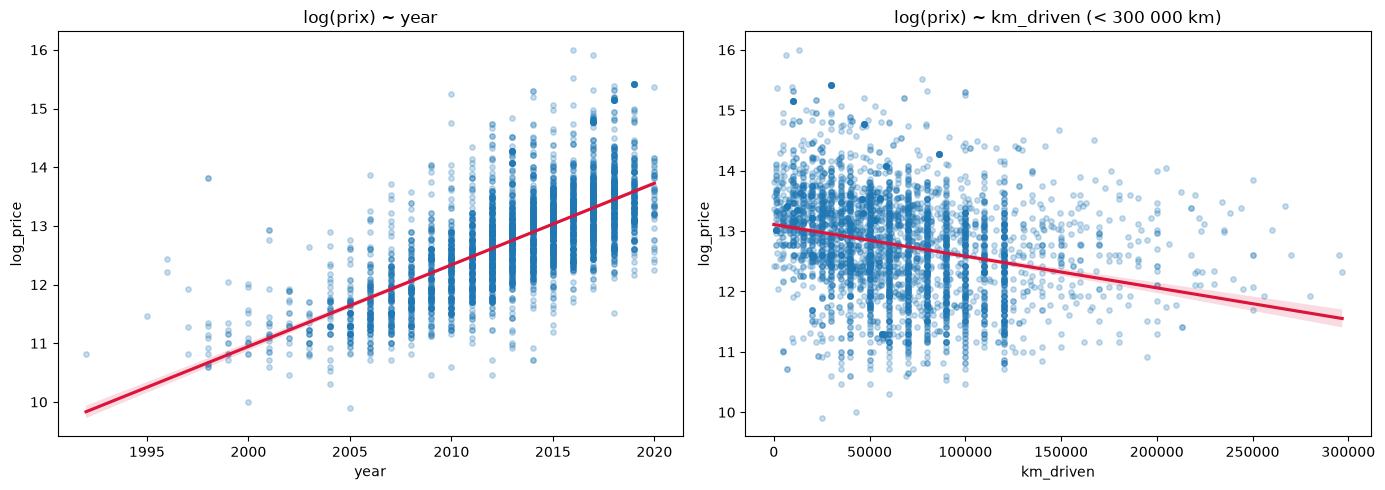

Corrélation log(prix) / year      : 0.697
Corrélation log(prix) / km_driven : -0.241


In [16]:
# La relation est bien plus nette en échelle log sur le prix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
tmp = df.dropna(subset=["year", "km_driven"]).copy()
tmp["log_price"] = np.log1p(tmp["selling_price"])

sns.regplot(data=tmp, x="year", y="log_price", ax=axes[0],
            scatter_kws={"alpha": .25, "s": 15}, line_kws={"color": "crimson"})
axes[0].set_title("log(prix) ~ year")

sns.regplot(data=tmp[tmp["km_driven"] < 300_000], x="km_driven", y="log_price", ax=axes[1],
            scatter_kws={"alpha": .25, "s": 15}, line_kws={"color": "crimson"})
axes[1].set_title("log(prix) ~ km_driven (< 300 000 km)")

fig.tight_layout()
plt.show()

print("Corrélation log(prix) / year      :", round(tmp["log_price"].corr(tmp["year"]), 3))
print("Corrélation log(prix) / km_driven :", round(tmp["log_price"].corr(tmp["km_driven"]), 3))

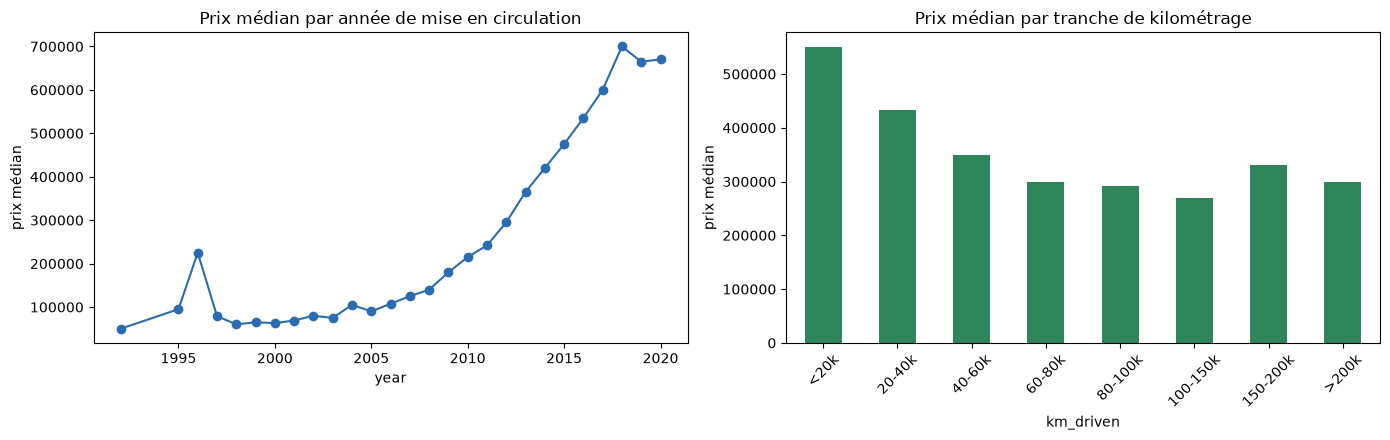

In [17]:
# Prix médian par année et par tranche de kilométrage : la tendance sans le bruit
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

by_year = df.groupby("year")["selling_price"].median()
by_year.plot(marker="o", ax=axes[0], color="#2b6cb0")
axes[0].set_title("Prix médian par année de mise en circulation")
axes[0].set_ylabel("prix médian")

bins = [0, 20_000, 40_000, 60_000, 80_000, 100_000, 150_000, 200_000, np.inf]
labels = ["<20k", "20-40k", "40-60k", "60-80k", "80-100k", "100-150k", "150-200k", ">200k"]
km_bin = pd.cut(df["km_driven"], bins=bins, labels=labels)
df.groupby(km_bin, observed=True)["selling_price"].median().plot(kind="bar", ax=axes[1], color="#2f855a")
axes[1].set_title("Prix médian par tranche de kilométrage")
axes[1].set_ylabel("prix médian")
axes[1].tick_params(axis="x", rotation=45)

fig.tight_layout()
plt.show()

**Lecture des corrélations**

| Paire | Pearson | Interprétation |
|---|---|---|
| `year` ↔ `selling_price` | **+0,41** | plus le véhicule est récent, plus il est cher |
| `km_driven` ↔ `selling_price` | **-0,19** | plus il a roulé, moins il vaut cher |
| `year` ↔ `km_driven` | **-0,42** | un véhicule ancien a logiquement plus de kilomètres |

Trois conclusions :

1. **`year` est le prédicteur numérique le plus fort.** Le prix médian passe d'environ
   100 000 pour les véhicules d'avant 2005 à plus de 600 000 pour ceux de 2018-2020.
2. **`km_driven` a un effet réel mais atténué en linéaire (-0,19)** : la relation n'est pas
   droite mais **décroissante et convexe** (la décote par kilomètre est forte au début puis
   s'aplatit), et elle est écrasée par la queue de distribution du prix. En passant en
   `log(prix)`, la corrélation se renforce nettement — ce qui confirme une relation
   **multiplicative** plutôt qu'additive. Le prix médian par tranche de kilométrage est
   monotone décroissant : le signal est bien là.
3. **`year` et `km_driven` sont corrélées entre elles (-0,42)** : il y a une redondance
   partielle, mais bien trop faible pour poser un problème de colinéarité. On conserve les deux.

---
## 5. Impact des variables catégorielles sur le prix

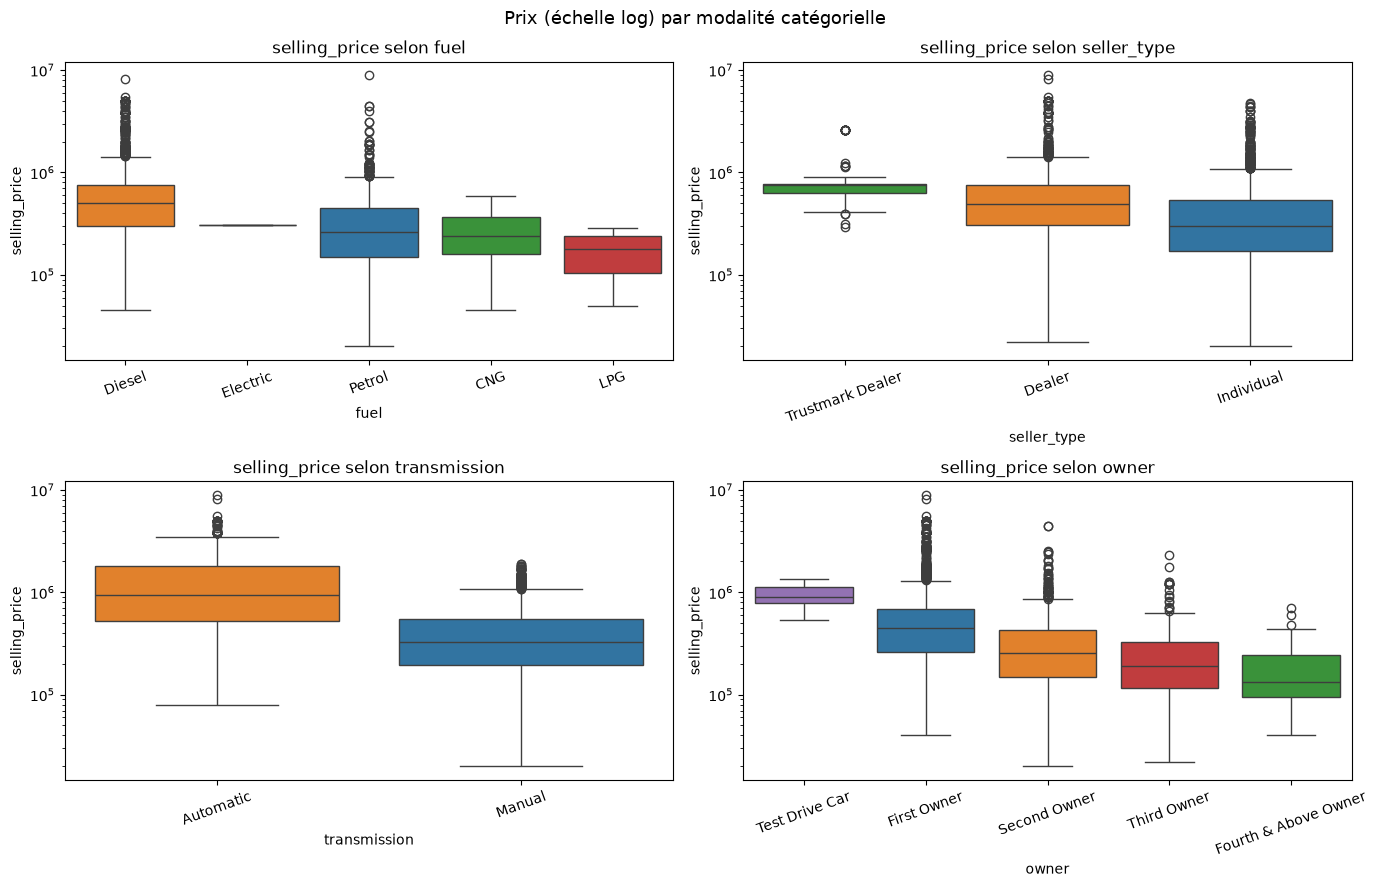

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.ravel(), cat_cols):
    order = df.groupby(col)["selling_price"].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y="selling_price", order=order, ax=ax, hue=col, legend=False)
    ax.set_yscale("log")   # échelle log : sinon les boîtes sont illisibles
    ax.set_title(f"selling_price selon {col}")
    ax.tick_params(axis="x", rotation=20)
fig.suptitle("Prix (échelle log) par modalité catégorielle", fontsize=13)
fig.tight_layout()
plt.show()

In [19]:
# Écart de prix médian entre modalités : mesure directe du pouvoir discriminant
for col in cat_cols:
    stats = df.groupby(col)["selling_price"].agg(["count", "median", "mean"]).sort_values("median", ascending=False)
    ecart = stats["median"].max() / stats["median"].min()
    print(f"--- {col} — rapport médiane max/min = {ecart:.2f}x ---")
    print(stats, "\n")

--- fuel — rapport médiane max/min = 2.78x ---
          count    median           mean
fuel                                    
Diesel     2116  500000.0  667709.321834
Electric      1  310000.0  310000.000000
Petrol     2077  265000.0  343913.246509
CNG          38  237499.5  275578.868421
LPG          22  180000.0  171818.136364 

--- seller_type — rapport médiane max/min = 2.50x ---
                  count    median           mean
seller_type                                     
Trustmark Dealer    101  750000.0  916485.148515
Dealer              976  495000.0  722953.845287
Individual         3198  300000.0  425380.107255 

--- transmission — rapport médiane max/min = 2.92x ---
              count    median          mean
transmission                               
Automatic       448  950000.0  1.408154e+06
Manual         3892  325000.0  4.000667e+05 

--- owner — rapport médiane max/min = 6.75x ---
                      count    median           mean
owner                        

29 marques distinctes pour 1491 libellés complets

               count     median
brand                          
Land               5  4000000.0
BMW               39  2600000.0
Mercedes-Benz     35  2500000.0
Jaguar             6  2025000.0
Volvo              4  1987500.0
MG                 2  1842500.0
Audi              60  1580000.0
Isuzu              1  1500000.0
Jeep               3  1490000.0
Kia                1  1300000.0


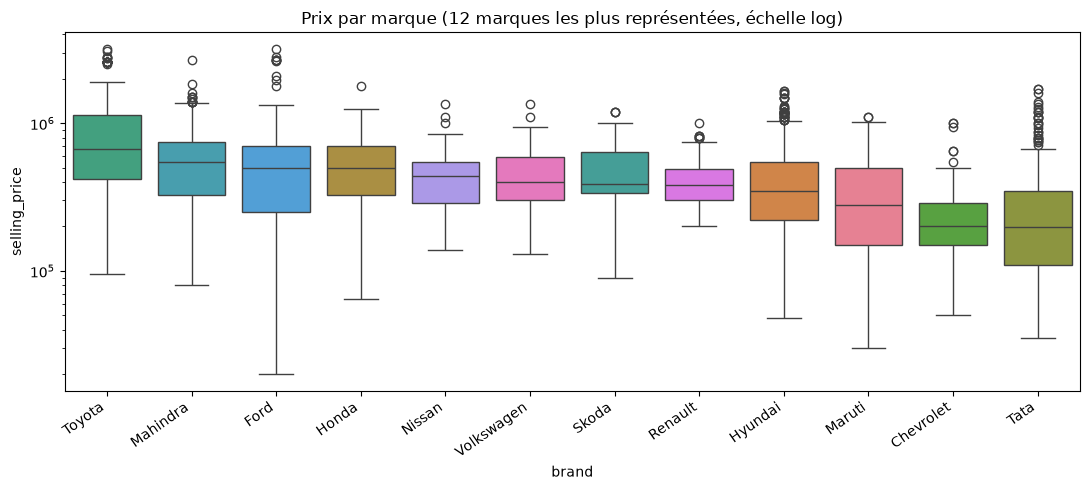

In [20]:
# La colonne `name` : 1491 modalités brutes, mais la marque est extractible
brand = df["name"].str.split().str[0]
print(f"{brand.nunique()} marques distinctes pour {df['name'].nunique()} libellés complets\n")

brand_stats = (df.assign(brand=brand)
                 .groupby("brand")["selling_price"]
                 .agg(["count", "median"])
                 .sort_values("median", ascending=False))
print(brand_stats.head(10))

top = brand.value_counts().head(12).index
plt.figure(figsize=(11, 5))
sns.boxplot(data=df.assign(brand=brand).query("brand in @top"),
            x="brand", y="selling_price",
            order=brand_stats.loc[brand_stats.index.isin(top)].index, hue="brand", legend=False)
plt.yscale("log")
plt.xticks(rotation=35, ha="right")
plt.title("Prix par marque (12 marques les plus représentées, échelle log)")
plt.tight_layout()
plt.show()

**Lecture**

- `transmission` est la catégorielle la plus discriminante : le prix médian d'une
  **automatique est plusieurs fois supérieur** à celui d'une manuelle (segment premium).
- `fuel` : Diesel > Petrol nettement ; CNG/LPG tirent vers le bas ; `Electric` (1 ligne)
  n'apporte statistiquement rien.
- `seller_type` : `Trustmark Dealer` > `Dealer` > `Individual` — le canal de vente porte
  une information réelle sur le segment du véhicule.
- `owner` : décroissance monotone du prix médian du 1er au 4e propriétaire → variable
  **ordinale** à encoder en respectant cet ordre. `Test Drive Car` se situe hors de cette
  échelle (prix élevés, véhicules quasi neufs).
- `name` : réduite à la **marque**, elle sépare très fortement les prix (Land Rover, BMW,
  Mercedes-Benz ≫ Maruti, Tata). L'information est donc réelle — mais elle est en grande
  partie déjà captée par `transmission` et `fuel`, et son exploitation demanderait un
  encodage spécifique (target/frequency encoding).

---
## 6. Justification des colonnes retenues pour la prédiction

| Colonne | Décision | Justification |
|---|---|---|
| `selling_price` | **Cible** | Variable à prédire. Fortement asymétrique (*skew* +4,9) → transformation `log` à envisager côté modélisation. |
| `year` | **Conservée** | Prédicteur numérique le plus corrélé au prix (**+0,41**) ; la décote annuelle est la mécanique économique centrale du marché de l'occasion. |
| `km_driven` | **Conservée** | Corrélation linéaire modérée (**-0,19**) mais relation clairement décroissante et monotone sur les prix médians par tranche ; effet bien plus net sur `log(prix)`. Deuxième déterminant métier de la décote. |
| `fuel` | **Conservée** | Écart de prix médian marqué entre Diesel/Petrol et CNG/LPG. *Réserve* : la modalité `Electric` (1 ligne) sera regroupée avec les modalités rares. |
| `seller_type` | **Conservée** | Trois modalités bien séparées en prix médian ; proxy du segment et du canal de vente. |
| `transmission` | **Conservée** | Variable binaire la plus discriminante du jeu de données (automatique ≫ manuelle). |
| `owner` | **Conservée (ordinale)** | Décroissance monotone du prix avec le rang du propriétaire. À encoder en préservant l'ordre, pas en one-hot. |
| `name` | **Écartée** | **1 491 modalités** pour 4 340 lignes : un one-hot exploserait la dimension (plus de colonnes que de lignes) et produirait un sur-apprentissage massif ; beaucoup de modalités n'apparaîtraient que dans le train ou que dans le test. La marque extraite reste une **piste d'amélioration** documentée, hors périmètre du prétraitement demandé (`fuel`, `seller_type`, `transmission`). |

### Périmètre retenu

- **Cible** : `selling_price`
- **Features numériques** : `year`, `km_driven`
- **Features catégorielles** : `fuel`, `seller_type`, `transmission`, `owner`

### Problèmes à corriger, identifiés par cette EDA

1. **Valeurs manquantes** : `km_driven` (173), `fuel` (86), `owner` (86), `seller_type` (65),
   `year` (43). La cible `selling_price` n'en a aucune — c'est essentiel, une ligne sans cible
   ne serait pas imputable mais à supprimer.
2. **Doublons** : **635 lignes strictement identiques** (≈ 14,6 % du jeu).
3. **Valeurs extrêmes** : queue droite marquée sur `selling_price` et `km_driven`
   (jusqu'à 806 599 km), queue gauche sur `year`. À trier entre *légitimes* et *incohérentes*.
4. **Types** : `year` / `km_driven` à recaster en entiers après imputation.
5. **Modalités rares** : `Electric` (1 obs.), `Test Drive Car` (17 obs.).
